# Price Elasticity Modeling

This analysis estimates the relationship between price and demand for
Cheerios 15 oz (UPC 1600066610), the highest-revenue cereal UPC in the
analysis sample.

Models are built progressively to examine how the estimated price elasticity
changes after accounting for recorded promotions, persistent differences
across stores, and common week-specific demand conditions.

Because prices are observational rather than randomly assigned, the estimated
coefficients are interpreted as conditional associations rather than definitive
causal effects.

In [1]:
from pathlib import Path

# Support kernels started in the repository root or notebooks directory.
PROJECT = Path.cwd().resolve()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
if not (PROJECT / "notebooks").is_dir() or not (PROJECT / "README.md").is_file():
    raise RuntimeError("Start the notebook from the repository root or notebooks directory.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

analysis = pd.read_parquet(
    PROJECT / "data" / "processed" / "cereal_analysis.parquet"
)

cheerios = analysis[
    analysis["UPC"] == 1600066610
].copy()

print(cheerios.shape)
cheerios.head()

(29679, 13)


,STORE,UPC,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK,DESCRIP,SIZE,UNIT_PRICE,REVENUE
755754,2,1600066610,1,84,1,2.9,None,22.31,1,CHEERIOS,15 OZ,2.9,243.6
755755,2,1600066610,2,64,1,2.9,None,21.00,1,CHEERIOS,15 OZ,2.9,185.6
755756,2,1600066610,3,84,1,2.9,None,21.59,1,CHEERIOS,15 OZ,2.9,243.6
755757,2,1600066610,4,90,1,2.9,None,20.34,1,CHEERIOS,15 OZ,2.9,261.0
755758,2,1600066610,5,60,1,2.9,None,18.83,1,CHEERIOS,15 OZ,2.9,174.0


## 1. Model Variables

A log-log demand specification is used so that the coefficient on log price
can be interpreted as an estimated price elasticity. Store-week observations
have positive quantity and price by construction, allowing both variables to
be log-transformed.

Recorded promotion codes are retained as categorical controls rather than
combined into a single promotion indicator because exploratory analysis showed
substantial differences across promotion types.

In [2]:
cheerios["LOG_QTY"] = np.log(cheerios["MOVE"])
cheerios["LOG_PRICE"] = np.log(cheerios["UNIT_PRICE"])

cheerios["SALE_CODE"] = (
    cheerios["SALE"]
    .fillna("NO_CODE")
    .astype("category")
)

cheerios[
    ["MOVE", "UNIT_PRICE", "LOG_QTY", "LOG_PRICE", "SALE_CODE"]
].head()

,MOVE,UNIT_PRICE,LOG_QTY,LOG_PRICE,SALE_CODE
755754,84,2.9,4.430817,1.064711,NO_CODE
755755,64,2.9,4.158883,1.064711,NO_CODE
755756,84,2.9,4.430817,1.064711,NO_CODE
755757,90,2.9,4.499810,1.064711,NO_CODE
755758,60,2.9,4.094345,1.064711,NO_CODE


## 2. Baseline Log-Log Model

The first model estimates the raw association between price and quantity
without additional controls. This serves as a baseline rather than the preferred
elasticity specification because price may be correlated with promotions,
store characteristics, and time-specific demand conditions.

In [3]:
model_1 = smf.ols(
    "LOG_QTY ~ LOG_PRICE",
    data=cheerios
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                LOG_QTY   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                 1.304e+04
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:24:37   Log-Likelihood:                -30127.
No. Observations:               29679   AIC:                         6.026e+04
Df Residuals:                   29677   BIC:                         6.027e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.4232      0.033    227.846      0.0

In [4]:
model_2 = smf.ols(
    "LOG_QTY ~ LOG_PRICE + C(SALE_CODE)",
    data=cheerios
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                LOG_QTY   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     3322.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:24:37   Log-Likelihood:                -28936.
No. Observations:               29679   AIC:                         5.788e+04
Df Residuals:                   29673   BIC:                         5.793e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [5]:
model_comparison = pd.DataFrame({
    "Model": [
        "1: Price only",
        "2: + Promotion controls"
    ],
    "Price Elasticity": [
        model_1.params["LOG_PRICE"],
        model_2.params["LOG_PRICE"]
    ],
    "Std. Error": [
        model_1.bse["LOG_PRICE"],
        model_2.bse["LOG_PRICE"]
    ],
    "R-squared": [
        model_1.rsquared,
        model_2.rsquared
    ],
    "Observations": [
        int(model_1.nobs),
        int(model_2.nobs)
    ]
})

model_comparison

,Model,Price Elasticity,Std. Error,R-squared,Observations
0,1: Price only,-3.236033,0.028336,0.305295,29679
1,2: + Promotion controls,-2.739039,0.032091,0.358866,29679


## 3. Store Fixed Effects

Stores differ substantially in their average sales levels. These differences
may reflect persistent characteristics such as store size, location, customer
base, or other factors that are not directly observed in the dataset.

Store fixed effects control for these time-invariant differences by allowing
each store to have its own baseline demand level. The price coefficient is
therefore identified more from price changes within stores over time rather
than persistent differences between stores.

In [6]:
model_3 = smf.ols(
    "LOG_QTY ~ LOG_PRICE + C(SALE_CODE) + C(STORE)",
    data=cheerios
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                LOG_QTY   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.545
Method:                 Least Squares   F-statistic:                     367.1
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:24:37   Log-Likelihood:                -23807.
No. Observations:               29679   AIC:                         4.781e+04
Df Residuals:                   29581   BIC:                         4.862e+04
Df Model:                          97                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [7]:
model_comparison = pd.DataFrame({
    "Model": [
        "1: Price only",
        "2: + Promotion controls",
        "3: + Store fixed effects"
    ],
    "Price Elasticity": [
        model_1.params["LOG_PRICE"],
        model_2.params["LOG_PRICE"],
        model_3.params["LOG_PRICE"]
    ],
    "Std. Error": [
        model_1.bse["LOG_PRICE"],
        model_2.bse["LOG_PRICE"],
        model_3.bse["LOG_PRICE"]
    ],
    "R-squared": [
        model_1.rsquared,
        model_2.rsquared,
        model_3.rsquared
    ],
    "Observations": [
        int(model_1.nobs),
        int(model_2.nobs),
        int(model_3.nobs)
    ]
})

model_comparison

,Model,Price Elasticity,Std. Error,R-squared,Observations
0,1: Price only,-3.236033,0.028336,0.305295,29679
1,2: + Promotion controls,-2.739039,0.032091,0.358866,29679
2,3: + Store fixed effects,-2.807094,0.027543,0.546225,29679


In [8]:
model_4 = smf.ols(
    "LOG_QTY ~ LOG_PRICE + C(SALE_CODE) + C(STORE) + C(WEEK)",
    data=cheerios
).fit()

print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:                LOG_QTY   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     316.8
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:24:38   Log-Likelihood:                -8921.9
No. Observations:               29679   AIC:                         1.877e+04
Df Residuals:                   29216   BIC:                         2.261e+04
Df Model:                         462                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [9]:
model_comparison = pd.DataFrame({
    "Model": [
        "1: Price only",
        "2: + Promotion controls",
        "3: + Store fixed effects",
        "4: + Week fixed effects"
    ],
    "Price Elasticity": [
        model_1.params["LOG_PRICE"],
        model_2.params["LOG_PRICE"],
        model_3.params["LOG_PRICE"],
        model_4.params["LOG_PRICE"]
    ],
    "Std. Error": [
        model_1.bse["LOG_PRICE"],
        model_2.bse["LOG_PRICE"],
        model_3.bse["LOG_PRICE"],
        model_4.bse["LOG_PRICE"]
    ],
    "R-squared": [
        model_1.rsquared,
        model_2.rsquared,
        model_3.rsquared,
        model_4.rsquared
    ],
    "Observations": [
        int(model_1.nobs),
        int(model_2.nobs),
        int(model_3.nobs),
        int(model_4.nobs)
    ]
})

model_comparison

,Model,Price Elasticity,Std. Error,R-squared,Observations
0,1: Price only,-3.236033,0.028336,0.305295,29679
1,2: + Promotion controls,-2.739039,0.032091,0.358866,29679
2,3: + Store fixed effects,-2.807094,0.027543,0.546225,29679
3,4: + Week fixed effects,-1.594898,0.042782,0.833580,29679


## 4. Clustered Standard Errors

Observations from the same store over time may have correlated regression
errors. The preferred specification therefore uses standard errors clustered
at the store level. Clustering changes the estimated uncertainty around the
coefficients but does not change the OLS coefficient estimates themselves.

In [10]:
model_4_clustered = smf.ols(
    "LOG_QTY ~ LOG_PRICE + C(SALE_CODE) + C(STORE) + C(WEEK)",
    data=cheerios
).fit(
    cov_type="cluster",
    cov_kwds={"groups": cheerios["STORE"]}
)

print("Price elasticity:",
      model_4_clustered.params["LOG_PRICE"])

print("Clustered standard error:",
      model_4_clustered.bse["LOG_PRICE"])

print("p-value:",
      model_4_clustered.pvalues["LOG_PRICE"])

print("95% confidence interval:")
print(
    model_4_clustered.conf_int().loc["LOG_PRICE"]
)

Price elasticity: -1.5948980779743518
Clustered standard error: 0.10198016977352696
p-value: 3.930482644157304e-55
95% confidence interval:
0   -1.794776
1   -1.395021
Name: LOG_PRICE, dtype: float64


In [11]:
cheerios["UNIT_PRICE"].quantile(
    [0.01, 0.025, 0.05, 0.10, 0.25, 0.50]
)

0.010    1.67
0.025    1.99
0.050    2.60
0.100    2.86
0.250    3.04
0.500    3.25
Name: UNIT_PRICE, dtype: float64

In [12]:
cheerios.groupby("SALE_CODE")["UNIT_PRICE"].quantile(
    [0.01, 0.05, 0.50]
)

/var/folders/3p/s29dw6mj3yd6lq552j0kn83w0000gn/T/ipykernel_10138/41028762.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cheerios.groupby("SALE_CODE")["UNIT_PRICE"].quantile(


SALE_CODE      
B          0.01    1.6700
           0.05    1.8000
           0.50    3.0400
C          0.01    2.6815
           0.05    2.8000
           0.50    3.0400
G          0.01    1.6600
           0.05    1.6710
           0.50    1.8200
NO_CODE    0.01    2.4100
           0.05    2.8000
           0.50    3.2500
S          0.01    1.6000
           0.05    1.6700
           0.50    2.3200
Name: UNIT_PRICE, dtype: float64

## 5. Sensitivity to Deep Discounts

Some observations contain unusually deep discounts relative to the product's
typical price. Rather than removing these observations from the primary model,
I estimate alternative specifications that exclude the lowest portions of the
observed price distribution.

This tests whether the estimated price elasticity is primarily driven by
extreme discount observations. The full sample remains the primary
specification unless there is evidence that the estimate is highly sensitive
to these observations.

In [13]:
price_cutoffs = {
    "Full sample": cheerios["UNIT_PRICE"].min(),
    "Exclude bottom 1%": cheerios["UNIT_PRICE"].quantile(0.01),
    "Exclude bottom 2.5%": cheerios["UNIT_PRICE"].quantile(0.025),
    "Exclude bottom 5%": cheerios["UNIT_PRICE"].quantile(0.05)
}

price_cutoffs

{'Full sample': np.float64(0.99),
 'Exclude bottom 1%': np.float64(1.67),
 'Exclude bottom 2.5%': np.float64(1.99),
 'Exclude bottom 5%': np.float64(2.6)}

In [14]:
sensitivity_results = []

for label, cutoff in price_cutoffs.items():

    sample = cheerios[
        cheerios["UNIT_PRICE"] >= cutoff
    ].copy()

    model = smf.ols(
        "LOG_QTY ~ LOG_PRICE + C(SALE_CODE) + C(STORE) + C(WEEK)",
        data=sample
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": sample["STORE"]}
    )

    sensitivity_results.append({
        "Sample": label,
        "Minimum Price": cutoff,
        "Observations": int(model.nobs),
        "Price Elasticity": model.params["LOG_PRICE"],
        "Clustered SE": model.bse["LOG_PRICE"],
        "p-value": model.pvalues["LOG_PRICE"]
    })

sensitivity_table = pd.DataFrame(sensitivity_results)

sensitivity_table

,Sample,Minimum Price,Observations,Price Elasticity,Clustered SE,p-value
0,Full sample,0.99,29679,-1.594898,0.101980,3.930483e-55
1,Exclude bottom 1%,1.67,29529,-1.382149,0.113009,2.137473e-34
2,Exclude bottom 2.5%,1.99,29177,-1.504155,0.151162,2.506953e-23
3,Exclude bottom 5%,2.60,28201,-1.071516,0.150838,1.214185e-12


In [15]:
no_code = cheerios[
    cheerios["SALE_CODE"] == "NO_CODE"
].copy()

model_no_code = smf.ols(
    "LOG_QTY ~ LOG_PRICE + C(STORE) + C(WEEK)",
    data=no_code
).fit(
    cov_type="cluster",
    cov_kwds={"groups": no_code["STORE"]}
)

print("Observations:", int(model_no_code.nobs))
print("Price elasticity:", model_no_code.params["LOG_PRICE"])
print("Clustered SE:", model_no_code.bse["LOG_PRICE"])
print("95% CI:")
print(model_no_code.conf_int().loc["LOG_PRICE"])

Observations: 26452
Price elasticity: -1.5648147174626814
Clustered SE: 0.1352425646235698
95% CI:
0   -1.829885
1   -1.299744
Name: LOG_PRICE, dtype: float64


## 6. Preferred Elasticity Estimate

The preferred full-sample specification estimates a price elasticity of
approximately -1.59 for Cheerios 15 oz. The estimate remains negative across
alternative samples and is similar (-1.56) when observations with recorded
promotion codes are excluded.

However, the estimated magnitude becomes smaller when the deepest discounts
are excluded, reaching approximately -1.07 after excluding the bottom 5% of
observed prices. This suggests that a constant-elasticity model may not fully
capture differences in demand response across the historical price range.

I therefore use the full-sample estimate as the primary elasticity estimate
while treating subsequent pricing scenarios as local, model-based simulations
rather than causal estimates of an optimal price.

In [16]:
elasticity = model_4_clustered.params["LOG_PRICE"]

price_changes = np.array([
    -0.10,
    -0.05,
     0.00,
     0.05,
     0.10
])

scenarios = pd.DataFrame({
    "Price Change": price_changes
})

scenarios["Price Index"] = (
    1 + scenarios["Price Change"]
)

scenarios["Quantity Index"] = (
    scenarios["Price Index"] ** elasticity
)

scenarios["Revenue Index"] = (
    scenarios["Price Index"] *
    scenarios["Quantity Index"]
)

scenarios["Quantity Change"] = (
    scenarios["Quantity Index"] - 1
)

scenarios["Revenue Change"] = (
    scenarios["Revenue Index"] - 1
)

scenarios

,Price Change,Price Index,Quantity Index,Revenue Index,Quantity Change,Revenue Change
0,-0.10,0.90,1.182983,1.064685,0.182983,0.064685
1,-0.05,0.95,1.085247,1.030985,0.085247,0.030985
2,0.00,1.00,1.000000,1.000000,0.000000,0.000000
3,0.05,1.05,0.925135,0.971392,-0.074865,-0.028608
4,0.10,1.10,0.858980,0.944878,-0.141020,-0.055122


In [17]:
scenario_display = scenarios.copy()

scenario_display["Price Change"] = (
    scenario_display["Price Change"] * 100
).round(1)

scenario_display["Quantity Change"] = (
    scenario_display["Quantity Change"] * 100
).round(2)

scenario_display["Revenue Change"] = (
    scenario_display["Revenue Change"] * 100
).round(2)

scenario_display[
    [
        "Price Change",
        "Quantity Change",
        "Revenue Change"
    ]
]

,Price Change,Quantity Change,Revenue Change
0,-10.0,18.30,6.47
1,-5.0,8.52,3.10
2,0.0,0.00,0.00
3,5.0,-7.49,-2.86
4,10.0,-14.10,-5.51


## 8. Revenue and Profitability

The elasticity model predicts that lower prices increase revenue for Cheerios
15 oz over the local scenarios considered. However, maximizing revenue is not
equivalent to maximizing profit because lower prices may reduce the margin
earned on each unit.

I therefore examine the dataset's gross-margin measure before making a pricing
recommendation.

In [18]:
cheerios["PROFIT"].describe()

count    29679.000000
mean        15.140416
std         11.863026
min        -96.060000
25%         13.600000
50%         16.830000
75%         18.960000
max         60.360000
Name: PROFIT, dtype: float64

In [19]:
cheerios["PROFIT"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01   -46.142
0.05     5.010
0.10     8.720
0.25    13.600
0.50    16.830
0.75    18.960
0.90    21.720
0.95    24.430
0.99    45.190
Name: PROFIT, dtype: float64

In [20]:
cheerios[
    ["UNIT_PRICE", "PROFIT"]
].corr()

,UNIT_PRICE,PROFIT
UNIT_PRICE,1.000000,0.592156
PROFIT,0.592156,1.000000


In [21]:
cheerios["PRICE_DECILE"] = pd.qcut(
    cheerios["UNIT_PRICE"],
    q=10,
    duplicates="drop"
)

margin_by_price = (
    cheerios.groupby(
        "PRICE_DECILE",
        observed=True
    )
    .agg(
        observations=("MOVE", "size"),
        avg_price=("UNIT_PRICE", "mean"),
        avg_margin_pct=("PROFIT", "mean"),
        median_margin_pct=("PROFIT", "median"),
        avg_units=("MOVE", "mean")
    )
    .reset_index()
)

margin_by_price

,PRICE_DECILE,observations,avg_price,avg_margin_pct,median_margin_pct,avg_units
0,"(0.989, 2.86]",3049,2.367238,-2.508573,9.89,206.734339
1,"(2.86, 2.99]",3588,2.926193,15.808880,17.00,70.098662
2,"(2.99, 3.09]",4046,3.075289,15.845601,15.86,65.772862
3,"(3.09, 3.19]",1855,3.171132,17.252383,16.86,87.299191
4,"(3.19, 3.25]",4962,3.236995,16.922479,17.39,38.077388
5,"(3.25, 3.29]",1383,3.286688,11.559544,9.78,35.437455
6,"(3.29, 3.35]",4770,3.347952,18.396839,16.44,46.890985
7,"(3.35, 3.38]",101,3.367327,20.795347,20.77,38.227723
8,"(3.38, 3.49]",3651,3.435286,19.848565,19.50,41.355519
9,"(3.49, 3.79]",2274,3.607427,18.420303,17.88,37.574758


## 9. Approximate Gross-Profit Analysis

Historical gross margins generally increase with price, while the deepest
discounts are associated with much lower margins despite substantially higher
unit sales. This illustrates why a revenue-maximizing price need not maximize
profit.

I use the reported gross-margin percentage to calculate an approximate implied
unit cost. Because the dataset's margin measure is based on accounting cost and
may contain measurement noise, this cost estimate is used for scenario analysis
rather than treated as a precisely observed economic marginal cost.

In [22]:
cheerios["IMPLIED_COST"] = (
    cheerios["UNIT_PRICE"] *
    (1 - cheerios["PROFIT"] / 100)
)

cheerios["IMPLIED_COST"].describe()

count    29679.000000
mean         2.654295
std          0.287270
min          0.658024
25%          2.523870
50%          2.671998
75%          2.825853
max          4.749837
Name: IMPLIED_COST, dtype: float64

In [23]:
cheerios["IMPLIED_COST"].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

0.01    1.587230
0.05    2.211174
0.25    2.523870
0.50    2.671998
0.75    2.825853
0.95    3.046212
0.99    3.067272
Name: IMPLIED_COST, dtype: float64

In [24]:
cost_by_week = (
    cheerios.groupby("WEEK")
    .agg(
        median_cost=("IMPLIED_COST", "median"),
        mean_cost=("IMPLIED_COST", "mean")
    )
    .reset_index()
)

cost_by_week[
    ["median_cost", "mean_cost"]
].describe()

,median_cost,mean_cost
count,366.000000,366.000000
mean,2.648167,2.647262
std,0.283038,0.283002
min,1.511116,1.516584
25%,2.508974,2.509095
50%,2.665677,2.664436
75%,2.823296,2.823926
max,3.744273,3.768868


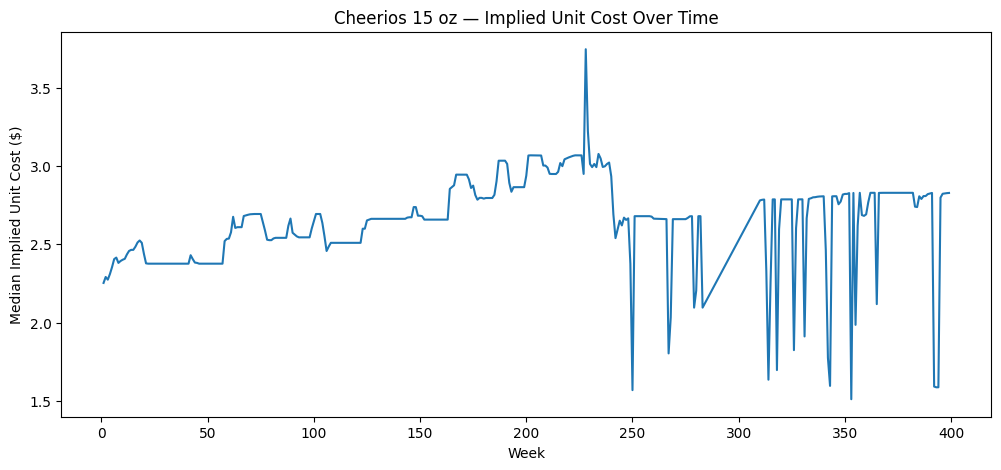

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    cost_by_week["WEEK"],
    cost_by_week["median_cost"]
)

plt.xlabel("Week")
plt.ylabel("Median Implied Unit Cost ($)")
plt.title("Cheerios 15 oz — Implied Unit Cost Over Time")

plt.show()

In [26]:
last_week = cheerios["WEEK"].max()

recent = cheerios[
    cheerios["WEEK"] > last_week - 26
].copy()

print("Weeks:",
      recent["WEEK"].min(),
      "to",
      recent["WEEK"].max())

print("Observations:", len(recent))

print("\nRecent price:")
print(recent["UNIT_PRICE"].describe())

print("\nRecent implied cost:")
print(recent["IMPLIED_COST"].describe())

Weeks: 374 to 399
Observations: 2156

Recent price:
count    2156.000000
mean        3.348752
std         0.194836
min         0.990000
25%         3.350000
50%         3.350000
75%         3.490000
max         3.490000
Name: UNIT_PRICE, dtype: float64

Recent implied cost:
count    2156.000000
mean        2.669896
std         0.393763
min         1.580260
25%         2.797235
50%         2.823975
75%         2.828070
max         2.828296
Name: IMPLIED_COST, dtype: float64


In [27]:
print(
    "Median recent price:",
    recent["UNIT_PRICE"].median()
)

print(
    "Median recent implied cost:",
    recent["IMPLIED_COST"].median()
)

print(
    "Median recent margin:",
    recent["PROFIT"].median()
)

Median recent price: 3.35
Median recent implied cost: 2.823975
Median recent margin: 16.2


## 10. Profit Scenario Assumptions

For the pricing scenarios, I use the median price and median implied unit cost
from the final 26 weeks of the sample as the reference point.

The reference price is $3.35 and the approximate implied unit cost is $2.824.
Holding this cost fixed across nearby price scenarios allows the analysis to
compare the predicted tradeoff between unit volume and gross margin.

Because the implied cost is derived from an accounting margin field and the
elasticity estimate is observational, these results should be interpreted as
model-based pricing scenarios rather than precise causal profit forecasts.

In [28]:
reference_price = recent["UNIT_PRICE"].median()
reference_cost = recent["IMPLIED_COST"].median()
elasticity = model_4_clustered.params["LOG_PRICE"]

profit_scenarios = pd.DataFrame({
    "Price Change": [-0.10, -0.05, 0.00, 0.05, 0.10]
})

profit_scenarios["Scenario Price"] = (
    reference_price *
    (1 + profit_scenarios["Price Change"])
)

profit_scenarios["Quantity Index"] = (
    (1 + profit_scenarios["Price Change"]) ** elasticity
)

profit_scenarios["Revenue Index"] = (
    (1 + profit_scenarios["Price Change"]) *
    profit_scenarios["Quantity Index"]
)

profit_scenarios["Gross Profit per Unit"] = (
    profit_scenarios["Scenario Price"] -
    reference_cost
)

baseline_gp_per_unit = (
    reference_price -
    reference_cost
)

profit_scenarios["Gross Profit Index"] = (
    profit_scenarios["Gross Profit per Unit"] *
    profit_scenarios["Quantity Index"]
    / baseline_gp_per_unit
)

profit_scenarios["Revenue Change"] = (
    profit_scenarios["Revenue Index"] - 1
)

profit_scenarios["Gross Profit Change"] = (
    profit_scenarios["Gross Profit Index"] - 1
)

profit_scenarios

,Price Change,Scenario Price,Quantity Index,Revenue Index,Gross Profit per Unit,Gross Profit Index,Revenue Change,Gross Profit Change
0,-0.10,3.0150,1.182983,1.064685,0.191025,0.429598,0.064685,-0.570402
1,-0.05,3.1825,1.085247,1.030985,0.358525,0.739676,0.030985,-0.260324
2,0.00,3.3500,1.000000,1.000000,0.526025,1.000000,0.000000,0.000000
3,0.05,3.5175,0.925135,0.971392,0.693525,1.219722,-0.028608,0.219722
4,0.10,3.6850,0.858980,0.944878,0.861025,1.406022,-0.055122,0.406022


In [29]:
profit_display = profit_scenarios.copy()

profit_display["Price Change"] = (
    profit_display["Price Change"] * 100
).round(1)

profit_display["Scenario Price"] = (
    profit_display["Scenario Price"]
).round(2)

profit_display["Quantity Change"] = (
    (profit_display["Quantity Index"] - 1) * 100
).round(2)

profit_display["Revenue Change"] = (
    profit_display["Revenue Change"] * 100
).round(2)

profit_display["Gross Profit Change"] = (
    profit_display["Gross Profit Change"] * 100
).round(2)

profit_display[
    [
        "Price Change",
        "Scenario Price",
        "Quantity Change",
        "Revenue Change",
        "Gross Profit Change"
    ]
]

,Price Change,Scenario Price,Quantity Change,Revenue Change,Gross Profit Change
0,-10.0,3.02,18.30,6.47,-57.04
1,-5.0,3.18,8.52,3.10,-26.03
2,0.0,3.35,0.00,0.00,0.00
3,5.0,3.52,-7.49,-2.86,21.97
4,10.0,3.69,-14.10,-5.51,40.60


## 11. Fine-Grid Pricing Analysis

The five initial pricing scenarios show that revenue and gross profit respond
differently to price changes. To examine the tradeoff more closely, I evaluate
a finer grid of prices around the recent reference price while remaining within
the historically observed price range.

These simulations hold the recent median implied unit cost fixed and apply the
estimated constant price elasticity. The resulting maximum is therefore a
model-implied benchmark, not a definitive optimal price recommendation.

In [30]:
price_grid = np.arange(
    2.75,
    cheerios["UNIT_PRICE"].max() + 0.001,
    0.01
)

pricing_grid = pd.DataFrame({
    "Scenario Price": price_grid
})

pricing_grid["Price Ratio"] = (
    pricing_grid["Scenario Price"] /
    reference_price
)

pricing_grid["Quantity Index"] = (
    pricing_grid["Price Ratio"] ** elasticity
)

pricing_grid["Revenue Index"] = (
    pricing_grid["Price Ratio"] *
    pricing_grid["Quantity Index"]
)

pricing_grid["Gross Profit per Unit"] = (
    pricing_grid["Scenario Price"] -
    reference_cost
)

pricing_grid["Gross Profit Index"] = (
    pricing_grid["Gross Profit per Unit"] *
    pricing_grid["Quantity Index"]
    / baseline_gp_per_unit
)

pricing_grid.head()

,Scenario Price,Price Ratio,Quantity Index,Revenue Index,Gross Profit per Unit,Gross Profit Index
0,2.75,0.820896,1.369942,1.124579,-0.073975,-0.192655
1,2.76,0.823881,1.362034,1.122153,-0.063975,-0.165650
2,2.77,0.826866,1.354200,1.119742,-0.053975,-0.138953
3,2.78,0.829851,1.346439,1.117344,-0.043975,-0.112561
4,2.79,0.832836,1.338751,1.114959,-0.033975,-0.086467


In [31]:
best_profit_row = pricing_grid.loc[
    pricing_grid["Gross Profit Index"].idxmax()
]

best_revenue_row = pricing_grid.loc[
    pricing_grid["Revenue Index"].idxmax()
]

print("Model-implied gross-profit maximum:")
print(best_profit_row)

print("\nHighest modeled revenue in grid:")
print(best_revenue_row)

Model-implied gross-profit maximum:
Scenario Price           3.790000
Price Ratio              1.131343
Quantity Index           0.821339
Revenue Index            0.929216
Gross Profit per Unit    0.966025
Gross Profit Index       1.508358
Name: 104, dtype: float64

Highest modeled revenue in grid:
Scenario Price           2.750000
Price Ratio              0.820896
Quantity Index           1.369942
Revenue Index            1.124579
Gross Profit per Unit   -0.073975
Gross Profit Index      -0.192655
Name: 0, dtype: float64


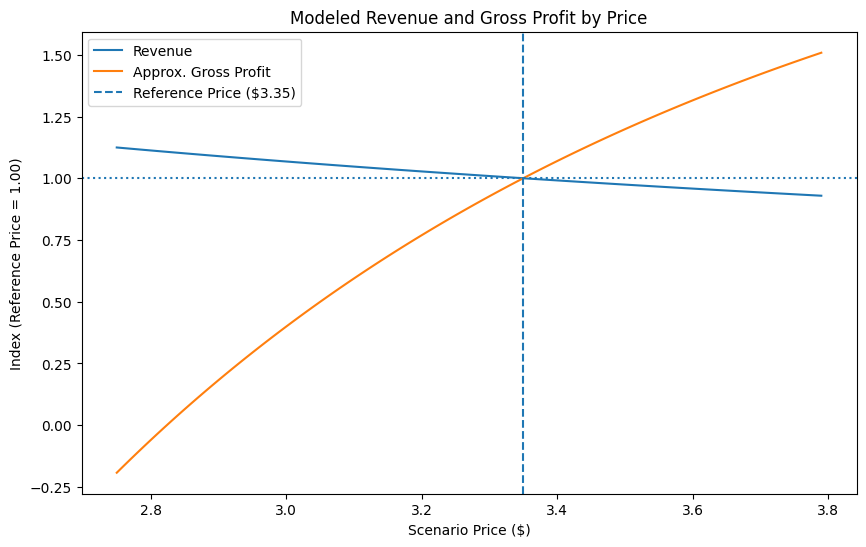

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(
    pricing_grid["Scenario Price"],
    pricing_grid["Revenue Index"],
    label="Revenue"
)

plt.plot(
    pricing_grid["Scenario Price"],
    pricing_grid["Gross Profit Index"],
    label="Approx. Gross Profit"
)

plt.axvline(
    reference_price,
    linestyle="--",
    label="Reference Price ($3.35)"
)

plt.axhline(
    1,
    linestyle=":"
)

plt.xlabel("Scenario Price ($)")
plt.ylabel("Index (Reference Price = 1.00)")
plt.title("Modeled Revenue and Gross Profit by Price")
plt.legend()

plt.show()

## 12. Pricing Recommendation

The pricing analysis reveals a tradeoff between revenue and gross profit.
Using the recent median price of $3.35 as the reference point, the model
predicts that a 5% price increase to approximately $3.52 would reduce revenue
by 2.9% but increase approximate gross profit by 22.0%. A 10% increase to
approximately $3.69 would reduce revenue by 5.5% while increasing approximate
gross profit by 40.6%.

Across the historically observed price range, modeled gross profit continues
to increase through the upper boundary rather than reaching an interior
maximum. Therefore, the analysis does not support claiming a specific
profit-maximizing price.

A reasonable business recommendation would be to test a moderate 5–10% price
increase ($3.52–$3.69) rather than immediately moving to the historical maximum.
This range offers substantial modeled gross-profit upside while limiting the
predicted revenue decline. A controlled pricing experiment could then measure
the causal demand response before a broader rollout.

These results should be interpreted as model-based scenarios rather than
causal forecasts because prices were not randomly assigned, the elasticity
model assumes a constant demand response, and approximate unit cost is derived
from the dataset's accounting margin measure.

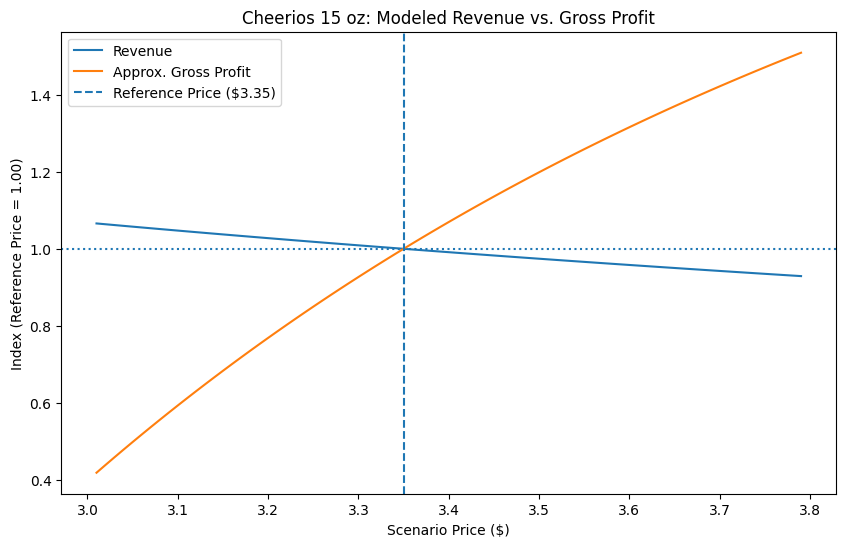

In [33]:
presentation_grid = pricing_grid[
    pricing_grid["Scenario Price"] >= 3.00
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    presentation_grid["Scenario Price"],
    presentation_grid["Revenue Index"],
    label="Revenue"
)

plt.plot(
    presentation_grid["Scenario Price"],
    presentation_grid["Gross Profit Index"],
    label="Approx. Gross Profit"
)

plt.axvline(
    reference_price,
    linestyle="--",
    label="Reference Price ($3.35)"
)

plt.axhline(
    1,
    linestyle=":"
)

plt.xlabel("Scenario Price ($)")
plt.ylabel("Index (Reference Price = 1.00)")
plt.title("Cheerios 15 oz: Modeled Revenue vs. Gross Profit")
plt.legend()

plt.show()

## 13. Multi-Product Elasticity Analysis

To assess whether the flagship Cheerios result generalizes across products,
I estimate the same preferred elasticity specification for the ten
highest-revenue cereal products.

Each product is modeled separately using recorded promotion controls, store
fixed effects, week fixed effects, and standard errors clustered by store.
Products are selected based on total historical revenue rather than their
estimated elasticity results.

In [34]:
top_products = (
    analysis.groupby(["UPC", "DESCRIP", "SIZE"])
    .agg(
        total_revenue=("REVENUE", "sum"),
        total_units=("MOVE", "sum"),
        observations=("MOVE", "size")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_products

,UPC,DESCRIP,SIZE,total_revenue,total_units,observations
71,1600066610,CHEERIOS,15 OZ,5715980.70,2011819,29679
70,1600066590,HONEY NUT CHEERIOS,14 OZ,4154655.73,1512370,29537
268,3800001520,KELLOGG'S FROSTED FL,20 OZ,3931466.34,1322703,29690
277,3800001720,KELLOGGS FRUIT LOOPS,15 OZ,3589030.75,1208611,29724
242,3800000120,KELLOGGS CORN FLAKES,18 OZ,3488292.49,1830189,29787
69,1600066510,CHEERIOS,10 OZ,3464034.91,1560241,29379
267,3800001510,KELLOGG'S FROSTED FL,15 OZ,3326669.72,1287272,29654
272,3800001621,KELLOGGS SPECIAL K,18 OZ,3143528.92,814409,29773
259,3800001011,KELLOGGS CORN POPS,15 OZ,3132156.62,1010399,29723
271,3800001611,KELLOGGS SPECIAL K,12 OZ,3120524.23,1077255,29771


### Portfolio Model Specification

For the multi-product analysis, I use a binary indicator for whether a
promotion code was recorded rather than separate promotion-code categories.

This avoids relying on sparsely observed or undocumented promotion categories
while retaining a control for observations explicitly marked with a promotion.
A blank promotion field is interpreted only as "no promotion code recorded,"
not as definitive evidence that no promotion occurred.

All products are estimated using the same specification with store and week
fixed effects and standard errors clustered by store.

In [35]:
portfolio_results = []
failed_products = []

for _, product in top_products.iterrows():

    upc = product["UPC"]

    product_data = analysis[
        analysis["UPC"] == upc
    ].copy()

    product_data["LOG_QTY"] = np.log(
        product_data["MOVE"]
    )

    product_data["LOG_PRICE"] = np.log(
        product_data["UNIT_PRICE"]
    )

    product_data["PROMO_RECORDED"] = (
        product_data["SALE"].notna().astype(int)
    )

    product_data = product_data[
        np.isfinite(product_data["LOG_QTY"]) &
        np.isfinite(product_data["LOG_PRICE"])
    ].copy()

    try:

        model = smf.ols(
            """
            LOG_QTY ~ LOG_PRICE
            + PROMO_RECORDED
            + C(STORE)
            + C(WEEK)
            """,
            data=product_data
        ).fit(
            cov_type="cluster",
            cov_kwds={
                "groups": product_data["STORE"]
            }
        )

        ci = model.conf_int().loc["LOG_PRICE"]

        portfolio_results.append({
            "UPC": upc,
            "Product": product["DESCRIP"],
            "Size": product["SIZE"],
            "Observations": int(model.nobs),
            "Stores": product_data["STORE"].nunique(),
            "Weeks": product_data["WEEK"].nunique(),
            "Elasticity": model.params["LOG_PRICE"],
            "Clustered SE": model.bse["LOG_PRICE"],
            "CI Lower": ci.iloc[0],
            "CI Upper": ci.iloc[1],
            "R Squared": model.rsquared
        })

    except Exception as e:

        failed_products.append({
            "UPC": upc,
            "Product": product["DESCRIP"],
            "Size": product["SIZE"],
            "Error": str(e)
        })

portfolio_elasticities = pd.DataFrame(
    portfolio_results
)

failed_products = pd.DataFrame(
    failed_products
)

portfolio_elasticities

,UPC,Product,Size,Observations,Stores,Weeks,Elasticity,Clustered SE,CI Lower,CI Upper,R Squared
0,1600066610,CHEERIOS,15 OZ,29679,93,366,-1.556790,0.103189,-1.759037,-1.354543,0.833314
1,1600066590,HONEY NUT CHEERIOS,14 OZ,29537,93,366,-0.817361,0.118937,-1.050474,-0.584248,0.810486
2,3800001520,KELLOGG'S FROSTED FL,20 OZ,29690,93,366,-1.840741,0.193097,-2.219203,-1.462279,0.787503
3,3800001720,KELLOGGS FRUIT LOOPS,15 OZ,29724,93,366,-1.772935,0.181303,-2.128282,-1.417588,0.784140
4,3800000120,KELLOGGS CORN FLAKES,18 OZ,29787,93,366,-1.805183,0.122114,-2.044523,-1.565843,0.837206
5,1600066510,CHEERIOS,10 OZ,29379,93,366,-0.794009,0.230320,-1.245429,-0.342590,0.756924
6,3800001510,KELLOGG'S FROSTED FL,15 OZ,29654,93,366,-1.639249,0.291890,-2.211343,-1.067154,0.743613
7,3800001621,KELLOGGS SPECIAL K,18 OZ,29773,93,366,-1.474459,0.242910,-1.950553,-0.998365,0.739881
8,3800001011,KELLOGGS CORN POPS,15 OZ,29723,93,366,-1.276501,0.215660,-1.699187,-0.853815,0.751524
9,3800001611,KELLOGGS SPECIAL K,12 OZ,29771,93,366,-1.198958,0.186180,-1.563864,-0.834051,0.748785


In [36]:
failed_products

""


## 14. Portfolio Elasticity Results

The multi-product analysis shows substantial heterogeneity in price sensitivity
across the ten highest-revenue cereal products.

Most products have estimated elasticities below -1, implying that modeled unit
sales respond proportionally more than price. However, Honey Nut Cheerios
14 oz and Cheerios 10 oz have point estimates between -1 and 0, indicating
relatively less price-sensitive demand.

This suggests that a uniform pricing strategy would be inappropriate. Products
with relatively inelastic demand may have more room for price increases from a
revenue perspective, while more elastic products face a larger volume and
revenue tradeoff.

These estimates remain observational and should be interpreted as conditional
associations rather than causal demand responses.

In [37]:
portfolio_elasticities["Demand Type"] = np.where(
    portfolio_elasticities["Elasticity"] < -1,
    "Elastic",
    "Inelastic"
)

portfolio_elasticities[
    [
        "Product",
        "Size",
        "Elasticity",
        "CI Lower",
        "CI Upper",
        "Demand Type"
    ]
]

,Product,Size,Elasticity,CI Lower,CI Upper,Demand Type
0,CHEERIOS,15 OZ,-1.556790,-1.759037,-1.354543,Elastic
1,HONEY NUT CHEERIOS,14 OZ,-0.817361,-1.050474,-0.584248,Inelastic
2,KELLOGG'S FROSTED FL,20 OZ,-1.840741,-2.219203,-1.462279,Elastic
3,KELLOGGS FRUIT LOOPS,15 OZ,-1.772935,-2.128282,-1.417588,Elastic
4,KELLOGGS CORN FLAKES,18 OZ,-1.805183,-2.044523,-1.565843,Elastic
5,CHEERIOS,10 OZ,-0.794009,-1.245429,-0.342590,Inelastic
6,KELLOGG'S FROSTED FL,15 OZ,-1.639249,-2.211343,-1.067154,Elastic
7,KELLOGGS SPECIAL K,18 OZ,-1.474459,-1.950553,-0.998365,Elastic
8,KELLOGGS CORN POPS,15 OZ,-1.276501,-1.699187,-0.853815,Elastic
9,KELLOGGS SPECIAL K,12 OZ,-1.198958,-1.563864,-0.834051,Elastic


In [38]:
portfolio_elasticities["Revenue Effect of Price Increase"] = np.where(
    portfolio_elasticities["Elasticity"] < -1,
    "Revenue likely decreases",
    "Revenue likely increases"
)

In [39]:
from pathlib import Path

# PROJECT is resolved in the first code cell.

EXPORTS = PROJECT / "outputs" / "python_results"
EXPORTS.mkdir(parents=True, exist_ok=True)

def standardize_columns(df):
    result = df.copy()
    result.columns = (
        result.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    return result

# Results for your ten modeled products
elasticities_export = standardize_columns(portfolio_elasticities)
elasticities_export["upc"] = elasticities_export["upc"].astype(str)
elasticities_export["model_id"] = "portfolio_binary_promo"

# Five Cheerios pricing scenarios
scenarios_export = standardize_columns(profit_scenarios)
scenarios_export["upc"] = "1600066610"
scenarios_export["model_id"] = "cheerios_categorical_promo"

# Detailed Cheerios price grid
grid_export = standardize_columns(pricing_grid)
grid_export["upc"] = "1600066610"
grid_export["model_id"] = "cheerios_categorical_promo"

# Save the assumptions with both scenario tables
for table in [scenarios_export, grid_export]:
    table["reference_price"] = float(reference_price)
    table["reference_cost"] = float(reference_cost)
    table["elasticity"] = float(
        model_4_clustered.params["LOG_PRICE"]
    )

elasticities_export.to_csv(
    EXPORTS / "product_elasticities.csv", index=False
)
scenarios_export.to_csv(
    EXPORTS / "pricing_scenarios.csv", index=False
)
grid_export.to_csv(
    EXPORTS / "pricing_grid.csv", index=False
)

print("Exports saved to:", EXPORTS)
print("Products:", len(elasticities_export))
print("Scenarios:", len(scenarios_export))
print("Grid points:", len(grid_export))

Exports saved to: /Users/anjangangisetty/Desktop/pricing-elasticity-project/outputs/python_results
Products: 10
Scenarios: 5
Grid points: 105
